<a href="https://colab.research.google.com/github/apekshatembhurne28-hash/apekshatembhurne28-ApekshaFML-practicals/blob/main/Task6_EE504.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 #============================================================
# SVM for Signal Quality Classification
# Wireless Communication System
# Kaggle IoT Transmission Dataset
# ============================================================


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

data = pd.read_csv(
    "iot_transmission_dataset.csv"
)


print("Dataset Preview:")
print(data.head())


print("\nDataset Columns:")
print(data.columns)



Dataset Preview:
   Signal_Strength_dBm  SNR_dB  Interference_dB  Distance_m  Frequency_GHz  \
0                  -41       6                0         257            5.0   
1                  -86      25               20         134            2.4   
2                  -73      27                0         385            2.4   
3                  -57       5                0         255            5.0   
4                  -87      15               24          61            5.0   

   Channel_Bandwidth_MHz  Noise_Floor_dBm  Connected_Devices  \
0                    160             -100                 24   
1                    160              -96                 41   
2                     20              -72                 13   
3                    160              -86                  9   
4                     20              -79                 32   

   Estimated_Throughput_Mbps Quality  
0                         18    Poor  
1                         55    Poor  
2           

In [ ]:
# ------------------------------------------------------------
# 2. Create Signal Quality Target
# ------------------------------------------------------------

# Check Quality classes
print("\nQuality Classes:")
print(data["Quality"].value_counts())

y = data["Quality"]


Quality Classes:
Quality
Poor         51
Fair         37
Good         10
Excellent     2
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
# 3. Encode Target
# ------------------------------------------------------------

encoder = LabelEncoder()

y = encoder.fit_transform(y)



print("\nTarget Classes:")
print(encoder.classes_)


Target Classes:
['Excellent' 'Fair' 'Good' 'Poor']


In [ ]:
# ------------------------------------------------------------
# 4. Select Features
# ------------------------------------------------------------

X = data[
    [
        "Signal_Strength_dBm",
        "SNR_dB",
        "Interference_dB",
        "Distance_m",
        "Frequency_GHz",
        "Channel_Bandwidth_MHz",
        "Noise_Floor_dBm",
        "Connected_Devices",
        "Estimated_Throughput_Mbps"
    ]
]

In [ ]:
# ------------------------------------------------------------
# 5. Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()


X = scaler.fit_transform(X)

In [ ]:
# ------------------------------------------------------------
# 6. Train-Test Split
# ------------------------------------------------------------


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [ ]:
# ------------------------------------------------------------
# 7. SVM Model
# ------------------------------------------------------------


model = SVC(

    kernel="rbf",

    C=1,

    gamma="scale"

)



# Training

model.fit(

    X_train,

    y_train

)


SVC(C=1)

In [ ]:
# ------------------------------------------------------------
# 8. Prediction
# ------------------------------------------------------------


y_pred = model.predict(

    X_test

)

In [ ]:
# ------------------------------------------------------------
# 9. Evaluation
# ------------------------------------------------------------


print("\nAccuracy:")

print(

    round(
        accuracy_score(
            y_test,
            y_pred
        )*100,
        2
    ),

    "%"

)



print("\nClassification Report:")


print(

    classification_report(

        y_test,

        y_pred,

        target_names=encoder.classes_

    )

)



Accuracy:
60.0 %

Classification Report:
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00         1
        Fair       0.50      0.43      0.46         7
        Good       0.00      0.00      0.00         2
        Poor       0.64      0.90      0.75        10

    accuracy                           0.60        20
   macro avg       0.29      0.33      0.30        20
weighted avg       0.50      0.60      0.54        20



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


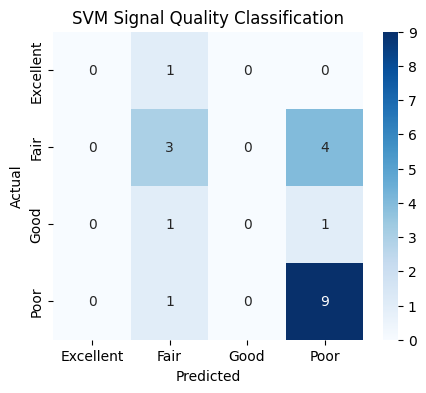

In [ ]:
# ------------------------------------------------------------
# 10. Confusion Matrix
# ------------------------------------------------------------


cm = confusion_matrix(

    y_test,

    y_pred

)



plt.figure(figsize=(5,4))


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=encoder.classes_,

    yticklabels=encoder.classes_

)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("SVM Signal Quality Classification")

plt.show()


In [ ]:
# ------------------------------------------------------------
# 11. Predict New Signal
# ------------------------------------------------------------

# Create the input sample as a DataFrame to keep feature names
new_signal_df = pd.DataFrame([[
    -60,     # Signal_Strength_dBm
    15,      # SNR_dB
    5,       # Interference_dB
    120,     # Distance_m
    2.4,     # Frequency_GHz
    40,      # Channel_Bandwidth_MHz
    -90,     # Noise_Floor_dBm
    10,      # Connected_Devices
    50       # Estimated_Throughput_Mbps
]], columns=[
    "Signal_Strength_dBm",
    "SNR_dB",
    "Interference_dB",
    "Distance_m",
    "Frequency_GHz",
    "Channel_Bandwidth_MHz",
    "Noise_Floor_dBm",
    "Connected_Devices",
    "Estimated_Throughput_Mbps"
])

new_signal_scaled = scaler.transform(
    new_signal_df
)

prediction = model.predict(
    new_signal_scaled
)
print("\nNew Signal Quality:")
print(
    encoder.inverse_transform(
        prediction
    )[0]
)


New Signal Quality:
Poor
